In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ashydv/advertising-dataset/advertising.csv


**Task 1: Load and Preprocess the Dataset**

**Import Libraries**

In [10]:
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

**Load Dataset**

In [11]:
df = pd.read_csv("/kaggle/input/datasets/ashydv/advertising-dataset/advertising.csv")

print(df.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


**Select Features and Target**

In [12]:
X = df[["TV", "Radio", "Newspaper"]]

y = df["Sales"]

**Normalize the Features**

In [13]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

**Split the Dataset**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Convert to PyTorch Tensors**

In [15]:
X_train = torch.tensor(X_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

**Task 2: Build the PyTorch Model**

In [16]:
model = nn.Linear(3,1)

print(model)

Linear(in_features=3, out_features=1, bias=True)


**Task 3: Train the Model
Loss Function and Optimizer**

In [17]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

**Training**

In [18]:
losses = []

for epoch in range(100):

    prediction = model(X_train)

    loss = loss_fn(prediction, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if (epoch+1)%10==0:
        print("Epoch:",epoch+1,"Loss:",loss.item())

Epoch: 10 Loss: 192.4021453857422
Epoch: 20 Loss: 128.4913330078125
Epoch: 30 Loss: 86.12195587158203
Epoch: 40 Loss: 58.02947998046875
Epoch: 50 Loss: 39.400489807128906
Epoch: 60 Loss: 27.04526138305664
Epoch: 70 Loss: 18.849720001220703
Epoch: 80 Loss: 13.412569999694824
Epoch: 90 Loss: 9.804800033569336
Epoch: 100 Loss: 7.410486698150635


**Task 4: Evaluate the Model**

In [19]:
with torch.no_grad():

    predicted = model(X_test)

mse = mean_squared_error(
    y_test.numpy(),
    predicted.numpy()
)

r2 = r2_score(
    y_test.numpy(),
    predicted.numpy()
)

print("Mean Squared Error:",mse)

print("R2 Score:",r2)

Mean Squared Error: 5.804762840270996
R2 Score: 0.8121502995491028


**Task 5: Visualize Results
Training Loss**

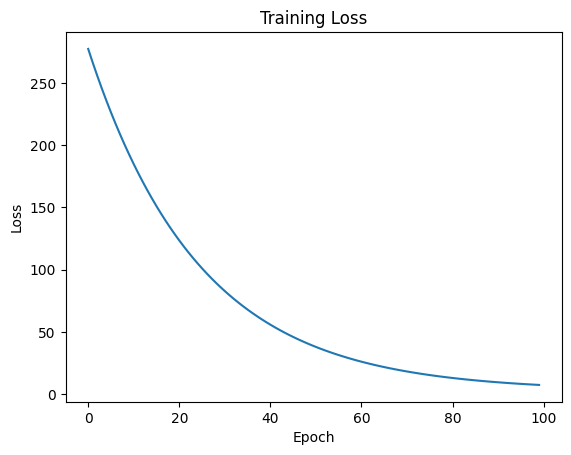

In [20]:
plt.plot(losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

**Actual vs Predicted Sales
**

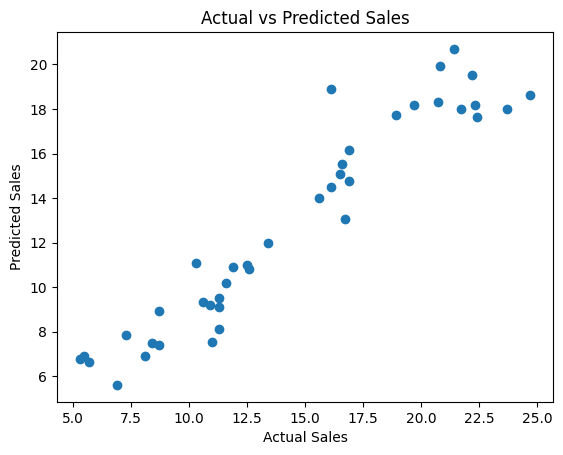

In [21]:
plt.scatter(
    y_test.numpy(),
    predicted.numpy()
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()


**Task 6: Conclusion
Conclusion**


Loaded and preprocessed the Advertising dataset.
Selected TV, Radio, and Newspaper as input features.
Built a simple Linear Regression model using PyTorch.
Trained the model using MSE Loss and the SGD optimizer.
Evaluated the model using Mean Squared Error (MSE) and R² Score.
The training loss decreased over epochs, and the predicted sales closely matched the actual sales, indicating that the model successfully learned the relationship between advertising expenses and sales.